In [15]:
""" Importing libraries phase"""

import numpy as np
import pandas as pd
import math as maths
from pathlib import Path


# Data vizualisation
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.metrics as metric
from sklearn.model_selection import train_test_split


import os
import sys

# Add path to find where to import our custom modules from
sys.path += ['Sai Bhone Myat Naing']


In [29]:
""" Data reading phase"""
# Location of Data

data_directory =  '../data/ml-1M/'

totalratingsdataset = os.path.join(data_directory,'ratings-cleaned.dat')


# Read dataset
"""List of the data sets"""
usersdata = pd.read_csv(os.path.join(data_directory, 'users-cleaned.dat'), sep='\t', header=None, encoding='latin-1')
moviesdata = pd.read_csv(os.path.join(data_directory, 'movies-cleaned.dat'), delimiter = '\t', header=None, encoding='latin-1')
ratingsdata = pd.read_csv(os.path.join(totalratingsdataset), delimiter = '\t', header=None, encoding='latin-1')

modeltrainingratingsdata = np.array(pd.read_csv(os.path.join(totalratingsdataset), sep = '\t'), dtype='int')




def dataconverting(data, numbers_of_users, numbers_of_movies ):
    newdata = []
    for userid in range(1, numbers_of_users + 1):
        moviesid = data[:,1][data[:,0] == userid]
        ratingsid = data[:,2][data[:,0] == userid]
        ratings = np.zeros(numbers_of_movies)
        ratings[moviesid - 1] = ratingsid
        newdata.append(list(ratings))
    return newdata


#Number of Users and Movies
numbers_of_movies = len(moviesdata)
print(numbers_of_movies)
numbers_of_users = len(usersdata)
print(numbers_of_users)


training_dataset, testing_dataset = train_test_split(modeltrainingratingsdata, test_size=0.2)
con_trainset = dataconverting(training_dataset,numbers_of_users, numbers_of_movies)
con_testset = dataconverting(testing_dataset,numbers_of_users, numbers_of_movies)
def split_train_and_valid(data, ratio):
    training_set = np.zeros((len(data), len(data[0]))).tolist()
    validation_set = np.zeros((len(data), len(data[0]))).tolist()

    for i in range(len(data)):
        for j in range(len(data[i])):
            if data[i][j] > 0:
                if np.random.binomial(1, ratio, 1):
                    training_set[i][j] = data[i][j]
                else:
                    validation_set[i][j] = data[i][j]

    return [training_set, validation_set]

"""Spliting data"""
train = split_train_and_valid(con_trainset, 0.6)
test = con_testset




3952
6040


In [30]:
"""Columns phase"""
moviesdata.columns = ['moviesID','Titles','Genre'] 
moviesdata.head()


,moviesID,Titles,Genre
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [19]:
"""Defining functions phase"""


def errorhandling(data, features=10, lr=0.0002, epochs=101, weigth_decay=0.02, stopping=0.001):

     
    train = data[0]
    valid = data[1]
    numbers_of_users = len(train)
    numbers_of_items = len(train[0])
    loss_train = []
    loss_valid = []
    P = np.random.rand(numbers_of_users, features) * 0.1
    Q = np.random.rand(numbers_of_items, features) * 0.1
    
    for e in range(epochs):        
        for u in range(numbers_of_users):
            for i in range(numbers_of_items):

                if train[u][i] > 0:
                    error_ui = train[u][i] - Matrix_Factorization(P, Q, u, i)
                    P, Q = sgd(error_ui, P, Q, u, i, features, lr, weigth_decay)
                               
     
        loss_train.append(MSE(train, P, Q))
        loss_valid.append(MSE(valid, P, Q))
        
        if e > 1:
            if abs(loss_valid[-1] - loss_valid[-2]) < stopping:
                break
        
    return P, Q, loss_train, loss_valid



def Matrix_Factorization(P, Q, u, i):

    return np.dot(P[u,:], Q[i,:])




In [23]:
def sgd(error, P, Q, id_user, id_item, features, lr, weigth_decay):
    
        
 
    for f in range(features):
        P[id_user, f] = P[id_user, f] + lr * (Q[id_item, f] * error -  weigth_decay * P[id_user, f])
        Q[id_item, f] = Q[id_item, f] + lr * (P[id_user, f] * error -  weigth_decay * Q[id_item, f])
      
    return P, Q



In [20]:
def top_rank(titles, ratings,k=1):
 
 
   # rank indices in descending order
   desc_ranks = np.argsort(ratings)[::-1]
 
   return titles[desc_ranks][:k], ratings[desc_ranks][:k]


In [21]:
"""Evaluations Phase"""
def MSE(data, P, Q):
   
    sum_of_error = 0.
    evaluation_count = 0
    numbers_of_users = len(data)
    numbers_of_items = len(data[0])
    
    for u in range(numbers_of_users):
        for i in range(numbers_of_items):
        
            
            if data[u][i] > 0:
                sum_of_error += pow(data[u][i] - Matrix_Factorization(P, Q, u, i), 2)
                evaluation_count += 1
    MSE = sum_of_error/evaluation_count
    return MSE

def RMSE(data, P, Q):
 
    sum_of_error = 0.
    evaluation_count = 0
    numbers_of_users = len(data)
    numbers_of_items = len(data[0])
    
    for u in range(numbers_of_users):
        for i in range(numbers_of_items):
        
            if data[u][i] > 0:
                sum_of_error += pow(data[u][i] - Matrix_Factorization(P, Q, u, i), 2)
                evaluation_count += 1
    RMSE = maths.sqrt(sum_of_error/evaluation_count)
    return RMSE

def MAE(data, P, Q):
   
    sum_of_error = 0.
    evaluation_count = 0
    numbers_of_users = len(data)
    numbers_of_items = len(data[0])
    
    for u in range(numbers_of_users):
        for i in range(numbers_of_items):
        
            if data[u][i] > 0:
                sum_of_error += abs(data[u][i] - Matrix_Factorization(P, Q, u, i))
                evaluation_count += 1
    
    MAE = sum_of_error/evaluation_count
    return MAE


In [24]:
features = 4
lr = 0.001
epochs = 101
weigth_decay = 0.01
stopping = 0.001

P, Q, loss_train, loss_valid = errorhandling(train, features, lr, epochs, weigth_decay, stopping)

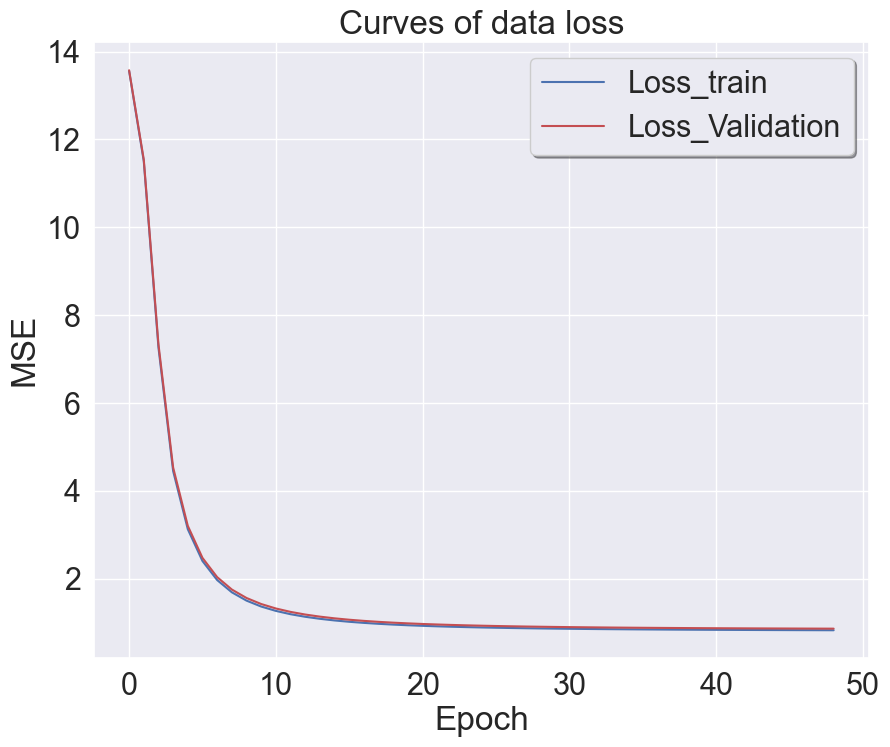

In [25]:
x = list(range(len(loss_train)))
k=0

sns.set(rc={'figure.figsize':(10,8)})
sns.set(font_scale = 2)

plt.plot(x[-k:], loss_train[-k:], 'b', label="Loss_train")
plt.plot(x[-k:], loss_valid[-k:], 'r', label="Loss_Validation")
plt.title('Curves of data loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
leg = plt.legend(loc='best', shadow=True, fancybox=True)

In [31]:
"""Presentation of recommendation for user phase"""

user_id = int(input("Enter User ID (1-6040):"))

topnumber = int(input("\nEnter Top Number movies:"))


user_train = np.array(train[0][user_id])

unseenmovies = np.where(user_train == 0, 1, 0)


MFPredict= np.dot(P[user_id, :], Q.T)

unseen_movie_predict = MFPredict * unseenmovies

recommendations, prediction_scores = top_rank(np.array(moviesdata['Titles']), unseen_movie_predict, k=topnumber)
print("\nTop",topnumber," highest rating movies for User_ID","[",user_id,"]")
top_n_recommended_data = pd.DataFrame(np.matrix((recommendations, prediction_scores)).T, (np.arange(topnumber) + 1).tolist(), 
                  columns=['Titles', 'Predicted rating'])

top_n_recommended_data



Top 4  highest rating movies for User_ID [ 67 ]


,Titles,Predicted rating
1,Crimes and Misdemeanors (1989),4.365809
2,Up in Smoke (1978),4.303616
3,Mina Tannenbaum (1994),4.270749
4,"Usual Suspects, The (1995)",4.269985


In [32]:
"""Evaluation Result"""
eval_table = [["MSE",MSE(test, P, Q)],
        ["RMSE",RMSE(test, P, Q)],
        ["MAE",MAE(test, P, Q)]]

df = pd.DataFrame(eval_table, columns = ['Evaluation Method','Deviation'])

df

,Evaluation Method,Deviation
0,MSE,0.847717
1,RMSE,0.920716
2,MAE,0.726679


Text(0, 0.5, 'Errors')

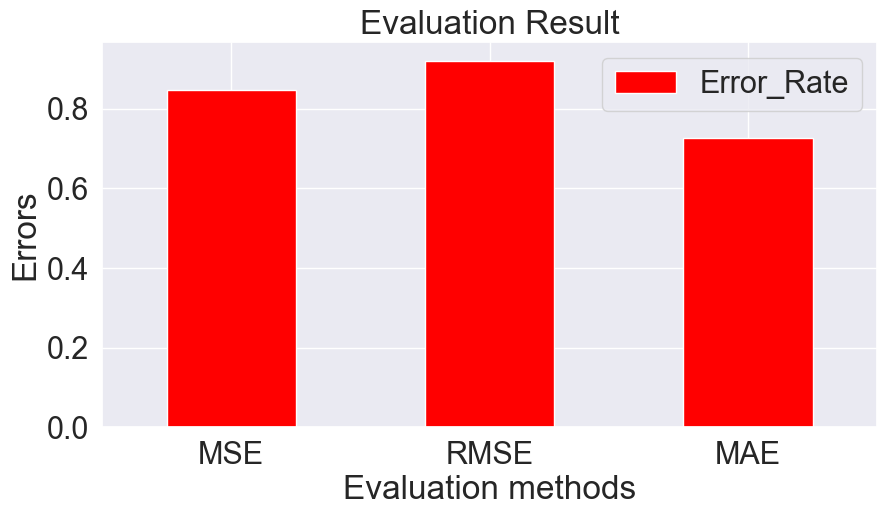

In [33]:
plotdata = pd.DataFrame({"Error_Rate": [MSE(test, P, Q), RMSE(test, P, Q), MAE(test, P, Q)]}, 
    index=["MSE", "RMSE", "MAE"])

plotdata.plot(kind = "bar", color = ['red'], figsize = (10,5)
)

plt.xticks(rotation = 0)
plt.title("Evaluation Result")
plt.xlabel("Evaluation methods")
plt.ylabel("Errors")